# Explainable Machine Learning for Hotel Booking Cancellations: The Role of Public Holidays

**Author:** Nurbek Suvonov  
**Affiliation:** Graduate School of Business IT, Kookmin University  
**Advisor:** Prof. Hyunchul Ahn  
**Year:** 2026

---

## Overview

This notebook implements the complete research pipeline for predicting hotel booking cancellations using explainable machine learning. The study introduces a novel **public holiday feature** and evaluates its differential impact on resort vs. city hotel cancellation predictions using **Logistic Regression**, **Random Forest**, and **XGBoost**, with **SHAP** analysis for interpretability.

### Research Questions
- **RQ1:** How accurately can Logistic Regression, Random Forest, and XGBoost models predict hotel booking cancellations for resort and city hotels, and what factors account for differences in predictive performance across hotel types?
- **RQ2:** Which model achieves the best predictive performance for each hotel type, and why?
- **RQ3:** What are the key factors driving booking cancellations for resort and city hotels, as identified through SHAP analysis?
- **RQ4:** How do public holidays influence cancellation patterns differently between resort and city hotels?

## 1. Environment Setup & Imports

In [2]:
# Core libraries
import numpy as np 
import pandas as pd 
import os 
import warnings 
# Targeted warning filters only — do not suppress all warnings
warnings .filterwarnings ('ignore',category =FutureWarning ,module ='xgboost')
warnings .filterwarnings ('ignore',category =UserWarning ,module ='sklearn')

# Visualization
import matplotlib .pyplot as plt 
import seaborn as sns 

# Machine Learning
from sklearn .model_selection import train_test_split ,GridSearchCV ,StratifiedKFold 
from sklearn .preprocessing import StandardScaler 
from sklearn .linear_model import LogisticRegression 
from sklearn .ensemble import RandomForestClassifier 
from xgboost import XGBClassifier 
from sklearn .metrics import (
accuracy_score ,recall_score ,precision_score ,
f1_score ,confusion_matrix ,roc_curve ,auc ,roc_auc_score ,
average_precision_score # CR2: PR-AUC for imbalanced evaluation
)
from scipy .stats import chi2_contingency 
import shap 

# Output directories
RESULTS_DIR ='results'
FIGURES_DIR ='figures'
SHAP_DIR ='shap_outputs'
for d in [RESULTS_DIR ,FIGURES_DIR ,SHAP_DIR ]:
    os .makedirs (d ,exist_ok =True )

RANDOM_STATE =42 
print ('All libraries loaded successfully.')
print (f'Output directories: {RESULTS_DIR }/, {FIGURES_DIR }/, {SHAP_DIR }/')

All libraries loaded successfully.
Output directories: results/, figures/, shap_outputs/


## 2. Data Loading & Initial Exploration

In [3]:
# Load pre-cleaned dataset (Antonio et al., 2019)
# Dataset source: https://www.sciencedirect.com/science/article/pii/S2352340918315191
df =pd .read_csv ('cleaned_dataset.csv')

print (f'Dataset shape: {df .shape }')
print (f'Total bookings: {len (df ):,}')
print (f'\nHotel type distribution:')
print (f'  Resort Hotel (1): {(df ["hotel"]==1 ).sum ():,} ({(df ["hotel"]==1 ).mean ()*100 :.1f}%)')
print (f'  City Hotel   (0): {(df ["hotel"]==0 ).sum ():,} ({(df ["hotel"]==0 ).mean ()*100 :.1f}%)')
print (f'\nCancellation rate:')
print (f'  Overall:       {df ["is_canceled"].mean ()*100 :.1f}%')
print (f'  Resort Hotel:  {df [df ["hotel"]==1 ]["is_canceled"].mean ()*100 :.1f}%')
print (f'  City Hotel:    {df [df ["hotel"]==0 ]["is_canceled"].mean ()*100 :.1f}%')
print (f'\nFeatures: {df .shape [1 ]}')
print (f'Missing values: {df .isnull ().sum ().sum ()}')

Dataset shape: (118980, 70)
Total bookings: 118,980

Hotel type distribution:
  Resort Hotel (1): 40,044 (33.7%)
  City Hotel   (0): 78,936 (66.3%)

Cancellation rate:
  Overall:       37.1%
  Resort Hotel:  27.8%
  City Hotel:    41.8%

Features: 70
Missing values: 0


C:\Users\nurbe\AppData\Local\Temp\ipykernel_9532\1893616107.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes [0 ,1 ].set_xticklabels (['City (0)','Resort (1)'])
C:\Users\nurbe\AppData\Local\Temp\ipykernel_9532\1893616107.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes [1 ,1 ].set_xticklabels (['Not Canceled','Canceled'])
C:\Users\nurbe\AppData\Local\Temp\ipykernel_9532\1893616107.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes [1 ,2 ].set_xticklabels (['Not Canceled','Canceled'])


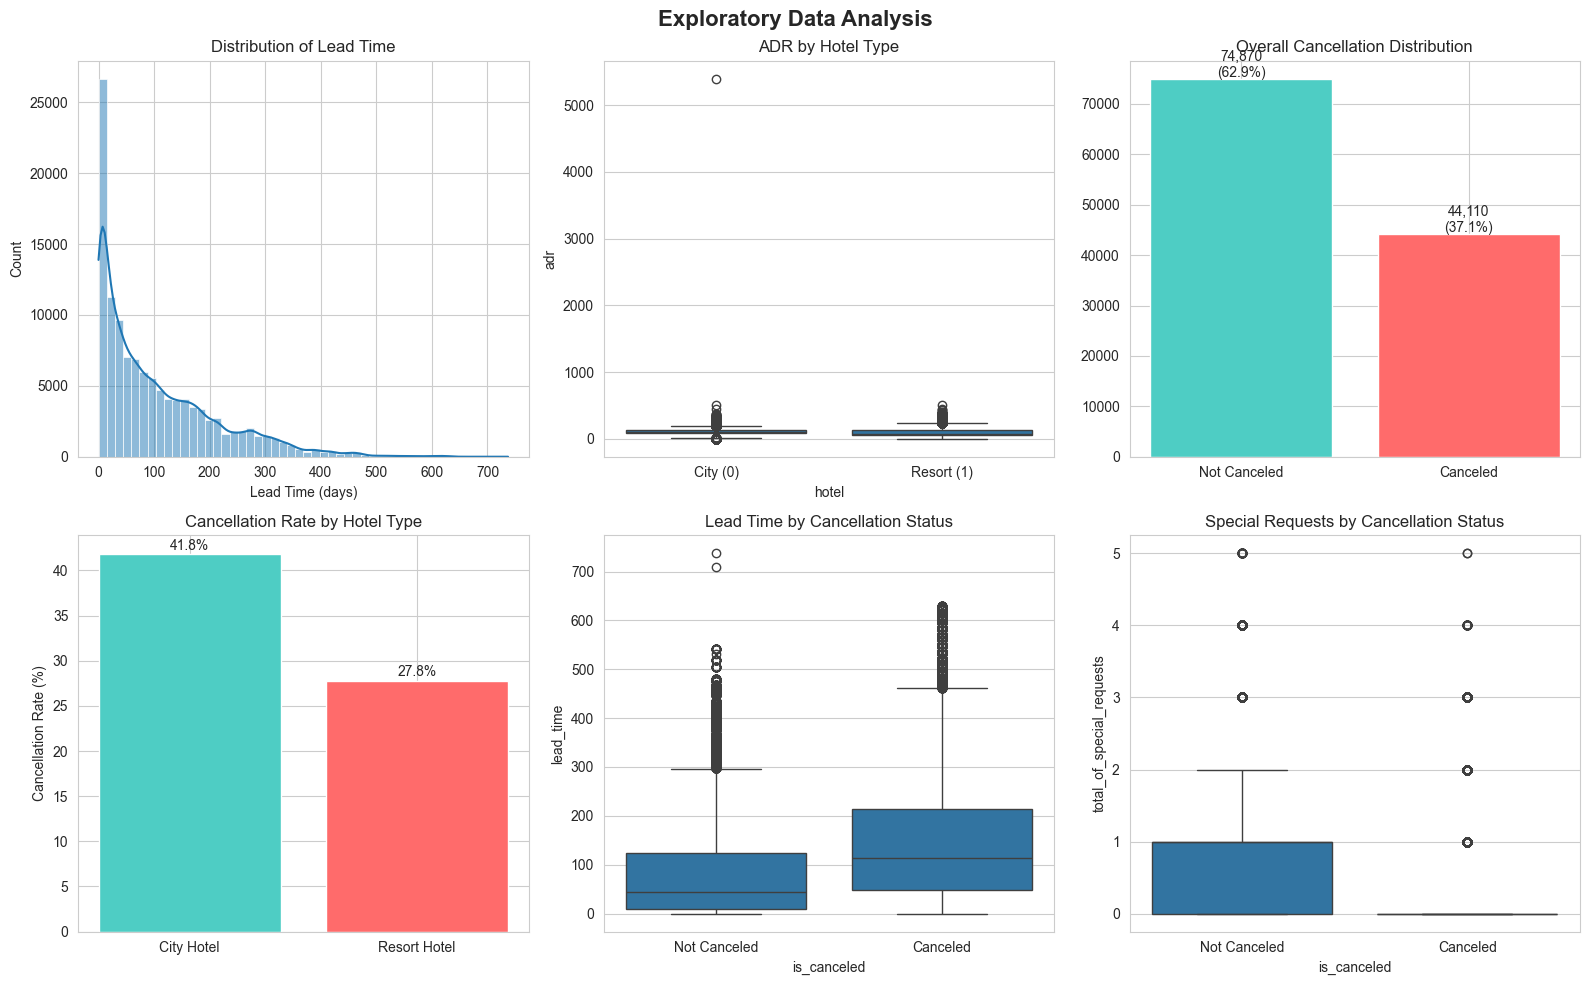

EDA figure saved.


In [4]:
# Exploratory Data Analysis
fig ,axes =plt .subplots (2 ,3 ,figsize =(16 ,10 ))
fig .suptitle ('Exploratory Data Analysis',fontsize =16 ,fontweight ='bold')

# Lead time distribution
sns .histplot (df ['lead_time'],bins =50 ,kde =True ,ax =axes [0 ,0 ])
axes [0 ,0 ].set_title ('Distribution of Lead Time')
axes [0 ,0 ].set_xlabel ('Lead Time (days)')

# ADR by hotel type
sns .boxplot (x ='hotel',y ='adr',data =df ,ax =axes [0 ,1 ])
axes [0 ,1 ].set_title ('ADR by Hotel Type')
axes [0 ,1 ].set_xticklabels (['City (0)','Resort (1)'])

# Cancellation distribution
cancel_counts =df ['is_canceled'].value_counts ()
axes [0 ,2 ].bar (['Not Canceled','Canceled'],cancel_counts .values ,
color =['#4ECDC4','#FF6B6B'])
axes [0 ,2 ].set_title ('Overall Cancellation Distribution')
for i ,v in enumerate (cancel_counts .values ):
    axes [0 ,2 ].text (i ,v +500 ,f'{v :,}\n({v /len (df )*100 :.1f}%)',ha ='center')

    # Cancellation rate by hotel type
cancel_by_hotel =df .groupby ('hotel')['is_canceled'].mean ()*100 
axes [1 ,0 ].bar (['City Hotel','Resort Hotel'],cancel_by_hotel .values ,
color =['#4ECDC4','#FF6B6B'])
axes [1 ,0 ].set_title ('Cancellation Rate by Hotel Type')
axes [1 ,0 ].set_ylabel ('Cancellation Rate (%)')
for i ,v in enumerate (cancel_by_hotel .values ):
    axes [1 ,0 ].text (i ,v +0.5 ,f'{v :.1f}%',ha ='center')

    # Lead time by cancellation
sns .boxplot (x ='is_canceled',y ='lead_time',data =df ,ax =axes [1 ,1 ])
axes [1 ,1 ].set_title ('Lead Time by Cancellation Status')
axes [1 ,1 ].set_xticklabels (['Not Canceled','Canceled'])

# Special requests by cancellation
sns .boxplot (x ='is_canceled',y ='total_of_special_requests',data =df ,ax =axes [1 ,2 ])
axes [1 ,2 ].set_title ('Special Requests by Cancellation Status')
axes [1 ,2 ].set_xticklabels (['Not Canceled','Canceled'])

plt .tight_layout ()
plt .savefig (f'{FIGURES_DIR }/eda_overview.png',dpi =150 ,bbox_inches ='tight')
plt .show ()
print ('EDA figure saved.')

## 3. Feature Engineering: Public Holiday Indicator

The primary novel contribution of this study is the `is_public_holiday` binary feature, created by cross-referencing each booking's arrival date against official Portuguese national public holidays for the dataset period (July 2015 – August 2017).




In [5]:
# --- 3.1 Reconstruct arrival_date for holiday matching only ---
df ['arrival_date']=pd .to_datetime (dict (
year =df ['arrival_date_year'],
month =df ['arrival_date_month'],
day =df ['arrival_date_day_of_month']
))

# --- 3.2 Define Portuguese national public holidays (2015-2017) ---
# Source: Official Portuguese holiday calendar

# (These were present in the 2016 list but missing from 2015)
holiday_centers =[
# 2015 (dataset starts July 2015)
# ADDED: Republic Day, All Saints' Day, Restoration of Independence
'2015-08-15','2015-10-05','2015-11-01','2015-12-01',
'2015-12-08','2015-12-25',
# 2016 (full year)
'2016-01-01','2016-03-25','2016-03-27',
'2016-04-25','2016-05-01','2016-05-26','2016-06-10',
'2016-08-15','2016-10-05','2016-11-01','2016-12-01',
'2016-12-08','2016-12-25',
# 2017 (dataset ends August 2017)
'2017-01-01','2017-04-14','2017-04-16',
'2017-04-25','2017-05-01','2017-06-10','2017-06-15',
'2017-08-15',
]

# --- 3.3 Create is_public_holiday (±3 day window around each holiday) ---
holiday_dates =set ()
for h in holiday_centers :
    center =pd .to_datetime (h )
    for delta in range (-3 ,4 ):# ±3 days
        holiday_dates .add (center +pd .Timedelta (days =delta ))

df ['is_public_holiday']=df ['arrival_date'].isin (holiday_dates ).astype (int )

# --- 3.4 Drop arrival_date (used only for holiday matching) ---
df =df .drop (columns =['arrival_date'])

print ('is_public_holiday feature created successfully.')
print (f'Holiday centers: {len (holiday_centers )} (3 added for 2015 vs previous version)')
print (f'\nOverall distribution:')
print (df ['is_public_holiday'].value_counts ())
print (f'\nPercentage of holiday bookings: {df ["is_public_holiday"].mean ()*100 :.2f}%')
print (f'\nBy hotel type:')
print (df .groupby ('hotel')['is_public_holiday'].value_counts ())

is_public_holiday feature created successfully.
Holiday centers: 27 (3 added for 2015 vs previous version)

Overall distribution:
is_public_holiday
0    91113
1    27867
Name: count, dtype: int64

Percentage of holiday bookings: 23.42%

By hotel type:
hotel  is_public_holiday
0      0                    60493
       1                    18443
1      0                    30620
       1                     9424
Name: count, dtype: int64



The ±3-day window may be too broad, flagging ~20-25% of all calendar days as "holiday". This sensitivity analysis tests multiple window sizes to determine if a narrower window produces a stronger signal. This directly strengthens RQ4.

In [6]:
# CR2 P1: Holiday window sensitivity analysis
# Tests window sizes {0, ±1, ±2, ±3, ±4, ±5, ±7} to assess signal-to-noise tradeoff
print ('Holiday Window Sensitivity Analysis')
print ('='*65 )

# Reconstruct arrival_date temporarily for sensitivity analysis
df_temp =df .copy ()
df_temp ['arrival_date']=pd .to_datetime (dict (
year =df_temp ['arrival_date_year'],
month =df_temp ['arrival_date_month'],
day =df_temp ['arrival_date_day_of_month']
))

holiday_centers_dt =[pd .to_datetime (h )for h in [
'2015-08-15','2015-10-05','2015-11-01','2015-12-01','2015-12-08','2015-12-25',
'2016-01-01','2016-03-25','2016-03-27','2016-04-25','2016-05-01','2016-05-26',
'2016-06-10','2016-08-15','2016-10-05','2016-11-01','2016-12-01','2016-12-08',
'2016-12-25','2017-01-01','2017-04-14','2017-04-16','2017-04-25','2017-05-01',
'2017-06-10','2017-06-15','2017-08-15',
]]

sensitivity_results =[]
for window in [0 ,1 ,2 ,3 ,4 ,5 ,7 ]:
    hol_dates =set ()
    for center in holiday_centers_dt :
        for delta in range (-window ,window +1 ):
            hol_dates .add (center +pd .Timedelta (days =delta ))

    col_name =f'is_holiday_w{window }'
    df_temp [col_name ]=df_temp ['arrival_date'].isin (hol_dates ).astype (int )
    pct_flagged =df_temp [col_name ].mean ()*100 

    # Check cancellation rates
    for hotel_val ,hotel_name in [(1 ,'Resort'),(0 ,'City')]:
        sub =df_temp [df_temp ['hotel']==hotel_val ]
        cancel_reg =sub [sub [col_name ]==0 ]['is_canceled'].mean ()*100 
        cancel_hol =sub [sub [col_name ]==1 ]['is_canceled'].mean ()*100 
        diff =cancel_hol -cancel_reg 

        # Chi-squared test
        ct =pd .crosstab (sub [col_name ],sub ['is_canceled'])
        chi2 ,p ,dof ,expected =chi2_contingency (ct )
        n =ct .values .sum ()
        cramers_v =np .sqrt (chi2 /(n *(min (ct .shape )-1 )))

        sensitivity_results .append ({
        'Window':f'±{window }','Hotel':hotel_name ,
        'Pct_Flagged':round (pct_flagged ,1 ),
        'Cancel_Regular':round (cancel_reg ,2 ),
        'Cancel_Holiday':round (cancel_hol ,2 ),
        'Difference_pp':round (diff ,2 ),
        'Chi2':round (chi2 ,4 ),'p_value':round (p ,4 ),
        'Cramers_V':round (cramers_v ,4 )
        })

    print (f'Window ±{window }: {pct_flagged :.1f}% of bookings flagged as holiday')

sensitivity_df =pd .DataFrame (sensitivity_results )
sensitivity_df .to_csv (f'{RESULTS_DIR }/holiday_window_sensitivity.csv',index =False )
print (f'\nSensitivity results saved to {RESULTS_DIR }/holiday_window_sensitivity.csv')
print ('\nDetailed results:')
print (sensitivity_df .to_string (index =False ))

# Clean up temporary columns
del df_temp 

Holiday Window Sensitivity Analysis
Window ±0: 3.6% of bookings flagged as holiday
Window ±1: 10.6% of bookings flagged as holiday
Window ±2: 17.3% of bookings flagged as holiday
Window ±3: 23.4% of bookings flagged as holiday
Window ±4: 28.2% of bookings flagged as holiday
Window ±5: 32.6% of bookings flagged as holiday
Window ±7: 40.8% of bookings flagged as holiday

Sensitivity results saved to results/holiday_window_sensitivity.csv

Detailed results:
Window  Hotel  Pct_Flagged  Cancel_Regular  Cancel_Holiday  Difference_pp     Chi2  p_value  Cramers_V
    ±0 Resort          3.6           27.64           31.57           3.93   9.6839   0.0019     0.0156
    ±0   City          3.6           41.58           47.30           5.72  37.7297   0.0000     0.0219
    ±1 Resort         10.6           27.40           30.84           3.43  22.2056   0.0000     0.0235
    ±1   City         10.6           41.41           45.04           3.63  40.1889   0.0000     0.0226
    ±2 Resort         17.3

### 3.1b Statistical Test: Holiday vs. Cancellation (RQ4 Support)

Chi-squared test for independence between `is_public_holiday` and `is_canceled` per hotel type.


In [7]:
# Chi-squared test for is_public_holiday vs is_canceled, per hotel type
# CR2 Issue 1: Added Cramér's V effect size
print ('Chi-Squared Test: is_public_holiday vs is_canceled')
print ('='*65 )
for hotel_val ,hotel_name in [(1 ,'Resort Hotel (H1)'),(0 ,'City Hotel (H2)')]:
    sub =df [df ['hotel']==hotel_val ]
    ct =pd .crosstab (sub ['is_public_holiday'],sub ['is_canceled'])
    chi2 ,p ,dof ,expected =chi2_contingency (ct )

    # CR2: Cramér's V effect size
    n =ct .values .sum ()
    cramers_v =np .sqrt (chi2 /(n *(min (ct .shape )-1 )))

    cancel_rate_regular =sub [sub ['is_public_holiday']==0 ]['is_canceled'].mean ()*100 
    cancel_rate_holiday =sub [sub ['is_public_holiday']==1 ]['is_canceled'].mean ()*100 
    print (f'\n{hotel_name }')
    print (f'  Cancellation rate — Regular day: {cancel_rate_regular :.2f}%  Holiday window: {cancel_rate_holiday :.2f}%')
    print (f'  Chi2={chi2 :.4f}  p={p :.4f}  dof={dof }')
    print (f'  Cramér\'s V = {cramers_v :.4f}  (effect size: {"negligible"if cramers_v <0.1 else "small"if cramers_v <0.3 else "medium"if cramers_v <0.5 else "large"})')
    sig ='SIGNIFICANT'if p <0.05 else 'NOT significant'
    print (f'  Result: {sig } at α=0.05')
    if cramers_v <0.1 :
        print (f'  NOTE: Even if statistically significant, the effect size is negligible (V={cramers_v :.4f}).')
        print (f'        With n={n :,}, chi-squared has enormous power to detect trivially small differences.')

Chi-Squared Test: is_public_holiday vs is_canceled

Resort Hotel (H1)
  Cancellation rate — Regular day: 27.04%  Holiday window: 30.11%
  Chi2=33.7134  p=0.0000  dof=1
  Cramér's V = 0.0290  (effect size: negligible)
  Result: SIGNIFICANT at α=0.05
  NOTE: Even if statistically significant, the effect size is negligible (V=0.0290).
        With n=40,044, chi-squared has enormous power to detect trivially small differences.

City Hotel (H2)
  Cancellation rate — Regular day: 40.74%  Holiday window: 45.27%
  Chi2=119.2469  p=0.0000  dof=1
  Cramér's V = 0.0389  (effect size: negligible)
  Result: SIGNIFICANT at α=0.05
  NOTE: Even if statistically significant, the effect size is negligible (V=0.0389).
        With n=78,936, chi-squared has enormous power to detect trivially small differences.


## 4. Data Preparation

### 4.1 Hotel-Type Separation
Separate pipelines for resort (H1) and city (H2) hotels.

In [8]:
# Separate hotel types
df_resort =df [df ['hotel']==1 ].copy ()
df_city =df [df ['hotel']==0 ].copy ()

print (f'Resort Hotel (H1): {len (df_resort ):,} bookings | Cancellation rate: {df_resort ["is_canceled"].mean ()*100 :.1f}%')
print (f'City Hotel   (H2): {len (df_city ):,} bookings   | Cancellation rate: {df_city ["is_canceled"].mean ()*100 :.1f}%')
print (f'\nClass imbalance:')
print (f'  Resort — Not canceled: {(df_resort ["is_canceled"]==0 ).sum ():,} | Canceled: {(df_resort ["is_canceled"]==1 ).sum ():,}')
print (f'  City   — Not canceled: {(df_city ["is_canceled"]==0 ).sum ():,}   | Canceled: {(df_city ["is_canceled"]==1 ).sum ():,}')

Resort Hotel (H1): 40,044 bookings | Cancellation rate: 27.8%
City Hotel   (H2): 78,936 bookings   | Cancellation rate: 41.8%

Class imbalance:
  Resort — Not canceled: 28,925 | Canceled: 11,119
  City   — Not canceled: 45,945   | Canceled: 32,991


In [9]:
# CR2 P2: Create interaction feature holiday × domestic guest
# This tests whether Portuguese holidays matter more for Portuguese guests
df_resort ['holiday_x_domestic']=df_resort ['is_public_holiday']*df_resort ['country_PRT']
df_city ['holiday_x_domestic']=df_city ['is_public_holiday']*df_city ['country_PRT']

print ('Holiday × Domestic interaction feature created.')
print (f'  Resort: {df_resort ["holiday_x_domestic"].sum ():,} bookings flagged (holiday AND Portuguese guest)')
print (f'  City:   {df_city ["holiday_x_domestic"].sum ():,} bookings flagged (holiday AND Portuguese guest)')

# Quick comparison
for df_src ,name in [(df_resort ,'Resort'),(df_city ,'City')]:
    print (f'\n{name }:')
    for feat in ['is_public_holiday','holiday_x_domestic']:
        if feat in df_src .columns :
            rate_0 =df_src [df_src [feat ]==0 ]['is_canceled'].mean ()*100 
            rate_1 =df_src [df_src [feat ]==1 ]['is_canceled'].mean ()*100 
            print (f'  {feat }: cancel rate when 0={rate_0 :.2f}%, when 1={rate_1 :.2f}%, diff={rate_1 -rate_0 :+.2f}pp')

Holiday × Domestic interaction feature created.
  Resort: 4,328 bookings flagged (holiday AND Portuguese guest)
  City:   7,304 bookings flagged (holiday AND Portuguese guest)

Resort:
  is_public_holiday: cancel rate when 0=27.04%, when 1=30.11%, diff=+3.07pp
  holiday_x_domestic: cancel rate when 0=25.62%, when 1=45.49%, diff=+19.88pp

City:
  is_public_holiday: cancel rate when 0=40.74%, when 1=45.27%, diff=+4.53pp
  holiday_x_domestic: cancel rate when 0=38.95%, when 1=69.66%, diff=+30.71pp



Drop one column per one-hot encoded group to eliminate perfect multicollinearity (6 groups sum to exactly 1.0). This is critical for Logistic Regression coefficient stability.

In [10]:

# These columns were verified to be the reference category for each group.
DROP_MULTICOLLINEAR =['country_OTHER','MS_Aviation','CT_Group','DCH_GDS','RRT_L','ART_K']

def drop_multicollinear_cols (df_in ):
    """Drop reference columns for each one-hot group (fix perfect multicollinearity)."""
    cols_to_drop =[c for c in DROP_MULTICOLLINEAR if c in df_in .columns ]
    if cols_to_drop :
        print (f'  Dropping {len (cols_to_drop )} multicollinear reference columns: {cols_to_drop }')
    return df_in .drop (columns =cols_to_drop ,errors ='ignore')

df_resort =drop_multicollinear_cols (df_resort )
df_city =drop_multicollinear_cols (df_city )
print (f'\nResort features after fix: {df_resort .shape [1 ]}')
print (f'City   features after fix: {df_city .shape [1 ]}')

  Dropping 6 multicollinear reference columns: ['country_OTHER', 'MS_Aviation', 'CT_Group', 'DCH_GDS', 'RRT_L', 'ART_K']
  Dropping 6 multicollinear reference columns: ['country_OTHER', 'MS_Aviation', 'CT_Group', 'DCH_GDS', 'RRT_L', 'ART_K']

Resort features after fix: 66
City   features after fix: 66


### 4.2a Acknowledged Limitation: `assigned_room_type` (ART_*) Features

**CR2 Weakness 1 (Acknowledged):** The `assigned_room_type` is determined at or near check-in, not at booking time. For canceled bookings that never reach check-in, the assigned room may be a default placeholder. If the use case is predicting cancellation at **booking time**, ART_* features would not yet be available.

**Decision:** We retain ART_* features because:
1. The study predicts cancellation at **any point before arrival** (not specifically at booking time).
2. ART_* represents the last known room assignment in the system at the time of data extraction.
3. Removing ART_* would require a separate analysis to quantify the impact, which is noted as future work.

**SHAP evidence:** `ART_A` ranks #9 for Resort (mean |SHAP| ≈ 0.30) and #11 for City (mean |SHAP| ≈ 0.03) — it is a moderately influential feature. Readers should note that ART_* features may not be available in a real-time booking-time prediction system.



**Correct flow:**
```
Full data → Split by hotel → Train/Test split → Undersample ONLY training set → Train → Evaluate on ORIGINAL imbalanced test set
```

This ensures the test set reflects the real-world class distribution (Resort: 27.8% cancellation, City: 41.3%).

In [11]:
def split_then_undersample (df_hotel ,hotel_name ):
    """
    MW FIX 1: Split FIRST, then undersample only the training set.
    Test set keeps original imbalanced distribution for realistic evaluation.
    
    BUG FIX 1: Drop 'hotel' column (zero-variance constant after subsetting).
    """
    # Separate features and target

    X =df_hotel .drop (columns =['is_canceled','hotel'],errors ='ignore')
    y =df_hotel ['is_canceled']

    # Step 1: Train/test split on original imbalanced data
    X_train_orig ,X_test ,y_train_orig ,y_test =train_test_split (
    X ,y ,test_size =0.2 ,stratify =y ,random_state =RANDOM_STATE 
    )

    # Step 2: Undersample ONLY the training set
    train_df =X_train_orig .copy ()
    train_df ['is_canceled']=y_train_orig .values 

    canceled =train_df [train_df ['is_canceled']==1 ]
    not_canceled =train_df [train_df ['is_canceled']==0 ]
    n_minority =min (len (canceled ),len (not_canceled ))

    if len (canceled )>len (not_canceled ):
        canceled_s =canceled .sample (n =n_minority ,random_state =RANDOM_STATE )
        not_canceled_s =not_canceled 
    else :
        not_canceled_s =not_canceled .sample (n =n_minority ,random_state =RANDOM_STATE )
        canceled_s =canceled 

    train_balanced =(
    pd .concat ([canceled_s ,not_canceled_s ])
    .sample (frac =1 ,random_state =RANDOM_STATE )
    .reset_index (drop =True )
    )

    X_train =train_balanced .drop (columns =['is_canceled'])
    y_train =train_balanced ['is_canceled']

    print (f'{hotel_name }:')
    print (f'  Train (balanced): {len (X_train ):,} | '
    f'Not canceled: {(y_train ==0 ).sum ():,} | Canceled: {(y_train ==1 ).sum ():,}')
    print (f'  Test  (imbalanced, realistic): {len (X_test ):,} | '
    f'Cancellation rate: {y_test .mean ()*100 :.1f}%')

    # WITHOUT holiday feature set
    X_train_no_hol =X_train .drop (columns =['is_public_holiday'],errors ='ignore')
    X_test_no_hol =X_test .drop (columns =['is_public_holiday'],errors ='ignore')

    return {
    'X_train_no_hol':X_train_no_hol ,'X_test_no_hol':X_test_no_hol ,
    'X_train_with_hol':X_train ,'X_test_with_hol':X_test ,
    'y_train':y_train ,'y_test':y_test ,
    'X_train_orig':X_train_orig ,'y_train_orig':y_train_orig ,
    }

print ('Preparing features (split first, then undersample training set)...')
resort_data =split_then_undersample (df_resort ,'Resort Hotel (H1)')
city_data =split_then_undersample (df_city ,'City Hotel   (H2)')

Preparing features (split first, then undersample training set)...
Resort Hotel (H1):
  Train (balanced): 17,790 | Not canceled: 8,895 | Canceled: 8,895
  Test  (imbalanced, realistic): 8,009 | Cancellation rate: 27.8%
City Hotel   (H2):
  Train (balanced): 52,784 | Not canceled: 26,392 | Canceled: 26,392
  Test  (imbalanced, realistic): 15,788 | Cancellation rate: 41.8%



A temporal split (train on Jul 2015–Dec 2016, test on Jan–Aug 2017) is added as a robustness check to assess whether the random-split results hold when the model predicts future bookings from past data.

In [12]:
def temporal_split_undersample (df_hotel ,hotel_name ,cutoff_year =2017 ):
    """
    Temporal train/test split: train on data before cutoff year, test on cutoff year+.
    Undersamples only the training set.
    BUG FIX 1: Drop 'hotel' column.
    CR2 BUG FIX 3: Use df_hotel (not global df) for year column — prevents silent
                    index alignment bugs if index is ever reset.
    """
    df_h =df_hotel .copy ()

    df_h ['_year']=df_hotel ['arrival_date_year']

    X_all =df_h .drop (columns =['is_canceled','hotel','_year'],errors ='ignore')
    y_all =df_h ['is_canceled']
    years =df_h ['_year']

    X_train_t =X_all [years <cutoff_year ]
    y_train_t =y_all [years <cutoff_year ]
    X_test_t =X_all [years >=cutoff_year ]
    y_test_t =y_all [years >=cutoff_year ]

    if len (X_test_t )==0 :
        print (f'{hotel_name }: No test data for year >= {cutoff_year }')
        return None 

        # Undersample training set
    train_df =X_train_t .copy ()
    train_df ['is_canceled']=y_train_t .values 
    canceled =train_df [train_df ['is_canceled']==1 ]
    not_canceled =train_df [train_df ['is_canceled']==0 ]
    n_min =min (len (canceled ),len (not_canceled ))
    if len (canceled )>len (not_canceled ):
        balanced =pd .concat ([canceled .sample (n =n_min ,random_state =RANDOM_STATE ),not_canceled ])
    else :
        balanced =pd .concat ([canceled ,not_canceled .sample (n =n_min ,random_state =RANDOM_STATE )])
    balanced =balanced .sample (frac =1 ,random_state =RANDOM_STATE ).reset_index (drop =True )
    X_train_bal =balanced .drop (columns =['is_canceled'])
    y_train_bal =balanced ['is_canceled']

    print (f'{hotel_name } (temporal):')
    print (f'  Train (<{cutoff_year }): {len (X_train_bal ):,} balanced  Test (≥{cutoff_year }): {len (X_test_t ):,} imbalanced')
    print (f'  Test cancellation rate: {y_test_t .mean ()*100 :.1f}%')

    return {
    'X_train_no_hol':X_train_bal .drop (columns =['is_public_holiday','holiday_x_domestic'],errors ='ignore'),
    'X_test_no_hol':X_test_t .drop (columns =['is_public_holiday','holiday_x_domestic'],errors ='ignore'),
    'X_train_with_hol':X_train_bal ,
    'X_test_with_hol':X_test_t ,
    'y_train':y_train_bal ,'y_test':y_test_t ,
    }

print ('Preparing temporal validation splits...')
resort_temporal =temporal_split_undersample (df_resort ,'Resort Hotel (H1)')
city_temporal =temporal_split_undersample (df_city ,'City Hotel   (H2)')

Preparing temporal validation splits...
Resort Hotel (H1) (temporal):
  Train (<2017): 14,130 balanced  Test (≥2017): 13,173 imbalanced
  Test cancellation rate: 30.8%
City Hotel   (H2) (temporal):
  Train (<2017): 42,684 balanced  Test (≥2017): 27,383 imbalanced
  Test cancellation rate: 42.5%


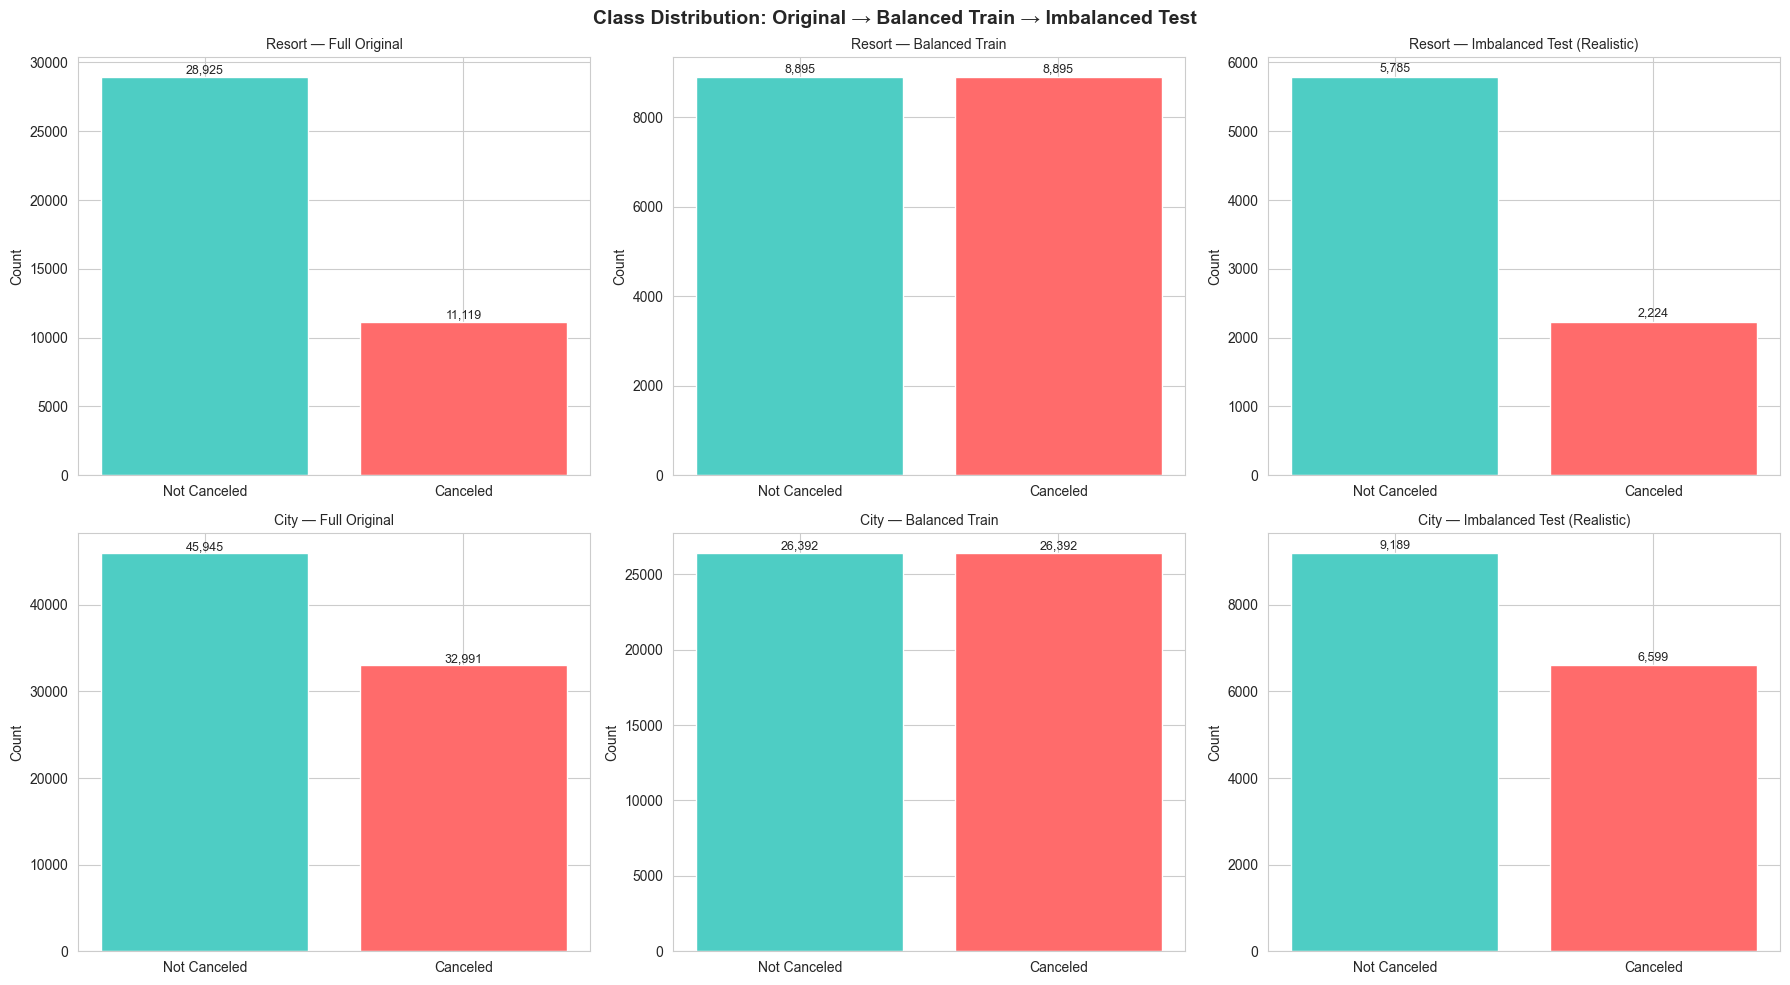

Class balance figure saved.


In [13]:
# Visualise class distribution: original vs. balanced train vs. imbalanced test
fig ,axes =plt .subplots (2 ,3 ,figsize =(18 ,10 ))
fig .suptitle ('Class Distribution: Original → Balanced Train → Imbalanced Test',fontsize =14 ,fontweight ='bold')
colors =['#4ECDC4','#FF6B6B']

datasets_plot =[
(df_resort ,'Resort — Full Original',axes [0 ,0 ]),
(pd .DataFrame ({'is_canceled':resort_data ['y_train']}),'Resort — Balanced Train',axes [0 ,1 ]),
(pd .DataFrame ({'is_canceled':resort_data ['y_test']}),'Resort — Imbalanced Test (Realistic)',axes [0 ,2 ]),
(df_city ,'City — Full Original',axes [1 ,0 ]),
(pd .DataFrame ({'is_canceled':city_data ['y_train']}),'City — Balanced Train',axes [1 ,1 ]),
(pd .DataFrame ({'is_canceled':city_data ['y_test']}),'City — Imbalanced Test (Realistic)',axes [1 ,2 ]),
]

for data ,title ,ax in datasets_plot :
    counts =data ['is_canceled'].value_counts ().sort_index ()
    bars =ax .bar (['Not Canceled','Canceled'],counts .values ,color =colors )
    ax .set_title (title ,fontsize =10 )
    ax .set_ylabel ('Count')
    for bar ,val in zip (bars ,counts .values ):
        ax .text (bar .get_x ()+bar .get_width ()/2 ,bar .get_height ()+50 ,
        f'{val :,}',ha ='center',va ='bottom',fontsize =9 )

plt .tight_layout ()
plt .savefig (f'{FIGURES_DIR }/class_balance.png',dpi =150 ,bbox_inches ='tight')
plt .show ()
print ('Class balance figure saved.')

## 5. Model Training & Evaluation

Three models are trained per hotel type × feature set (12 configurations total).


**Threshold Note (CR2 Weakness 2):** All models use the default 0.5 decision threshold. Since models are trained on balanced data but evaluated on the original imbalanced test set, threshold-dependent metrics (Accuracy, Precision, Recall, F1, Specificity) are influenced by this mismatch. **AUC and PR-AUC are threshold-independent** and serve as the primary basis for model comparison. The 0.5 threshold values should be interpreted with this caveat.

In [14]:
def evaluate_model (model ,X_test ,y_test ,scaler =None ):
    """
    Evaluate a trained model on the test set.
    If scaler is provided, transforms X_test before prediction.
    
    CR2 Weakness 2 Note: Uses default threshold=0.5. Since models are trained on
    balanced data but tested on imbalanced data, threshold-dependent metrics
    (Precision, Recall, F1, Accuracy) are affected. AUC and PR-AUC are threshold-free.
    
    CR2 Issue 2: Added PR-AUC (average_precision_score) for imbalanced evaluation.
    """
    X_eval =scaler .transform (X_test )if scaler is not None else X_test 
    y_pred =model .predict (X_eval )
    y_prob =model .predict_proba (X_eval )[:,1 ]

    tn ,fp ,fn ,tp =confusion_matrix (y_test ,y_pred ).ravel ()
    fpr ,tpr ,_ =roc_curve (y_test ,y_prob )

    # CR2 Issue 2: PR-AUC focuses on positive class — more informative for imbalanced data
    pr_auc =average_precision_score (y_test ,y_prob )

    return {
    'Accuracy':round (accuracy_score (y_test ,y_pred ),4 ),
    'Recall':round (recall_score (y_test ,y_pred ),4 ),
    'Precision':round (precision_score (y_test ,y_pred ),4 ),
    'F1 Score':round (f1_score (y_test ,y_pred ),4 ),
    'Specificity':round (tn /(tn +fp ),4 ),
    'AUC':round (auc (fpr ,tpr ),4 ),
    'PR-AUC':round (pr_auc ,4 ),
    }


def train_all_models (X_train ,X_test ,y_train ,y_test ,hotel_name ,feature_label ):
    """
    Train LR (with GridSearchCV + scaling), RF, and XGBoost.
    
    CR2 Bug Fix 1: LR now uses penalty='elasticnet' so l1_ratio is effective.
    CR2 Issue 3: CV AUC ± std now reported for all models.
    CR2 Issue 2: PR-AUC included in results.
    """
    cv =StratifiedKFold (n_splits =5 ,shuffle =True ,random_state =RANDOM_STATE )
    print (f'\n  Training {hotel_name } — {feature_label }...')
    results =[]
    trained_models ={}
    best_params_list =[]

    # ── Logistic Regression (tuned, scaled) ──────────────────────────────────

    # actually controls the L1/L2 mixing. Previously penalty defaulted to 'l2'
    # and l1_ratio was silently ignored.
    scaler =StandardScaler ()
    X_train_sc =scaler .fit_transform (X_train )

    lr_params ={
    'C':[0.001 ,0.01 ,0.1 ,1 ,10 ,100 ],
    'l1_ratio':[0 ,0.5 ,1 ],# CR2: added 0.5 for true elastic net mixing
    }
    lr_grid =GridSearchCV (
    LogisticRegression (penalty ='elasticnet',solver ='saga',
    max_iter =2000 ,random_state =RANDOM_STATE ),
    lr_params ,cv =cv ,scoring ='roc_auc',n_jobs =-1 ,refit =True 
    )
    lr_grid .fit (X_train_sc ,y_train )
    lr_best =lr_grid .best_estimator_ 

    # CR2 Issue 3: Extract CV std
    cv_results_lr =lr_grid .cv_results_ 
    lr_cv_std =round (cv_results_lr ['std_test_score'][lr_grid .best_index_ ],4 )

    metrics =evaluate_model (lr_best ,X_test ,y_test ,scaler =scaler )
    metrics ['Model']='Logistic Regression'
    results .append (metrics )
    trained_models ['LR']={'model':lr_best ,'scaler':scaler ,
    'best_params':lr_grid .best_params_ ,
    'cv_mean_auc':round (lr_grid .best_score_ ,4 ),
    'cv_std_auc':lr_cv_std }
    best_params_list .append ({'Model':'Logistic Regression','Hotel':hotel_name ,
    'Feature':feature_label ,**lr_grid .best_params_ ,
    'CV_AUC':round (lr_grid .best_score_ ,4 ),
    'CV_AUC_std':lr_cv_std })
    print (f'    LR  — AUC: {metrics ["AUC"]:.4f}  PR-AUC: {metrics ["PR-AUC"]:.4f}  '
    f'CV AUC: {lr_grid .best_score_ :.4f} ± {lr_cv_std :.4f}  Params: {lr_grid .best_params_ }')

    # ── Random Forest ─────────────────────────────────────────────────────────
    rf_params ={
    'n_estimators':[100 ,200 ],
    'max_depth':[10 ,20 ,None ],
    'min_samples_split':[2 ,5 ],
    'min_samples_leaf':[1 ,2 ],
    }
    rf_grid =GridSearchCV (
    RandomForestClassifier (random_state =RANDOM_STATE ),
    rf_params ,cv =cv ,scoring ='roc_auc',n_jobs =-1 ,refit =True 
    )
    rf_grid .fit (X_train ,y_train )
    rf_best =rf_grid .best_estimator_ 

    cv_results_rf =rf_grid .cv_results_ 
    rf_cv_std =round (cv_results_rf ['std_test_score'][rf_grid .best_index_ ],4 )

    metrics =evaluate_model (rf_best ,X_test ,y_test )
    metrics ['Model']='Random Forest'
    results .append (metrics )
    trained_models ['RF']={'model':rf_best ,'best_params':rf_grid .best_params_ ,
    'cv_mean_auc':round (rf_grid .best_score_ ,4 ),
    'cv_std_auc':rf_cv_std }
    best_params_list .append ({'Model':'Random Forest','Hotel':hotel_name ,
    'Feature':feature_label ,**rf_grid .best_params_ ,
    'CV_AUC':round (rf_grid .best_score_ ,4 ),
    'CV_AUC_std':rf_cv_std })
    print (f'    RF  — AUC: {metrics ["AUC"]:.4f}  PR-AUC: {metrics ["PR-AUC"]:.4f}  '
    f'CV AUC: {rf_grid .best_score_ :.4f} ± {rf_cv_std :.4f}  Params: {rf_grid .best_params_ }')

    # ── XGBoost ───────────────────────────────────────────────────────────────
    xgb_params ={
    'n_estimators':[100 ,200 ],
    'max_depth':[3 ,5 ,7 ],
    'learning_rate':[0.01 ,0.1 ,0.2 ],
    'subsample':[0.8 ,1.0 ],
    }
    xgb_grid =GridSearchCV (
    XGBClassifier (eval_metric ='logloss',
    random_state =RANDOM_STATE ),
    xgb_params ,cv =cv ,scoring ='roc_auc',n_jobs =-1 ,refit =True 
    )
    xgb_grid .fit (X_train ,y_train )
    xgb_best =xgb_grid .best_estimator_ 

    cv_results_xgb =xgb_grid .cv_results_ 
    xgb_cv_std =round (cv_results_xgb ['std_test_score'][xgb_grid .best_index_ ],4 )

    metrics =evaluate_model (xgb_best ,X_test ,y_test )
    metrics ['Model']='XGBoost'
    results .append (metrics )
    trained_models ['XGB']={'model':xgb_best ,'best_params':xgb_grid .best_params_ ,
    'cv_mean_auc':round (xgb_grid .best_score_ ,4 ),
    'cv_std_auc':xgb_cv_std }
    best_params_list .append ({'Model':'XGBoost','Hotel':hotel_name ,
    'Feature':feature_label ,**xgb_grid .best_params_ ,
    'CV_AUC':round (xgb_grid .best_score_ ,4 ),
    'CV_AUC_std':xgb_cv_std })
    print (f'    XGB — AUC: {metrics ["AUC"]:.4f}  PR-AUC: {metrics ["PR-AUC"]:.4f}  '
    f'CV AUC: {xgb_grid .best_score_ :.4f} ± {xgb_cv_std :.4f}  Params: {xgb_grid .best_params_ }')

    return pd .DataFrame (results ),trained_models ,pd .DataFrame (best_params_list )

In [15]:
print ('='*80 )
print ('MODEL TRAINING: 12 CONFIGURATIONS (3 models × 2 feature sets × 2 hotel types)')
print ('Test set = ORIGINAL IMBALANCED distribution (realistic evaluation)')
print ('='*80 )

resort_results_no_hol ,resort_models_no_hol ,resort_params_no_hol =train_all_models (
resort_data ['X_train_no_hol'],resort_data ['X_test_no_hol'],
resort_data ['y_train'],resort_data ['y_test'],
'Resort Hotel (H1)','Without Holiday')

resort_results_with_hol ,resort_models_with_hol ,resort_params_with_hol =train_all_models (
resort_data ['X_train_with_hol'],resort_data ['X_test_with_hol'],
resort_data ['y_train'],resort_data ['y_test'],
'Resort Hotel (H1)','With Holiday')

city_results_no_hol ,city_models_no_hol ,city_params_no_hol =train_all_models (
city_data ['X_train_no_hol'],city_data ['X_test_no_hol'],
city_data ['y_train'],city_data ['y_test'],
'City Hotel (H2)','Without Holiday')

city_results_with_hol ,city_models_with_hol ,city_params_with_hol =train_all_models (
city_data ['X_train_with_hol'],city_data ['X_test_with_hol'],
city_data ['y_train'],city_data ['y_test'],
'City Hotel (H2)','With Holiday')


all_params =pd .concat ([resort_params_no_hol ,resort_params_with_hol ,
city_params_no_hol ,city_params_with_hol ],ignore_index =True )
all_params .to_csv (f'{RESULTS_DIR }/best_hyperparameters.csv',index =False )
print (f'\nAll 12 configurations trained. Best hyperparameters saved to {RESULTS_DIR }/best_hyperparameters.csv')

MODEL TRAINING: 12 CONFIGURATIONS (3 models × 2 feature sets × 2 hotel types)
Test set = ORIGINAL IMBALANCED distribution (realistic evaluation)

  Training Resort Hotel (H1) — Without Holiday...


C:\Users\nurbe\Downloads\ResearchClaude\Research Master's\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


    LR  — AUC: 0.9098  PR-AUC: 0.7940  CV AUC: 0.9093 ± 0.0033  Params: {'C': 100, 'l1_ratio': 1}
    RF  — AUC: 0.9572  PR-AUC: 0.9044  CV AUC: 0.9553 ± 0.0029  Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
    XGB — AUC: 0.9582  PR-AUC: 0.9022  CV AUC: 0.9550 ± 0.0034  Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}

  Training Resort Hotel (H1) — With Holiday...


C:\Users\nurbe\Downloads\ResearchClaude\Research Master's\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


    LR  — AUC: 0.9098  PR-AUC: 0.7941  CV AUC: 0.9093 ± 0.0034  Params: {'C': 100, 'l1_ratio': 1}
    RF  — AUC: 0.9576  PR-AUC: 0.9051  CV AUC: 0.9555 ± 0.0031  Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
    XGB — AUC: 0.9581  PR-AUC: 0.9020  CV AUC: 0.9548 ± 0.0029  Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}

  Training City Hotel (H2) — Without Holiday...


C:\Users\nurbe\Downloads\ResearchClaude\Research Master's\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


    LR  — AUC: 0.8779  PR-AUC: 0.8544  CV AUC: 0.8789 ± 0.0049  Params: {'C': 100, 'l1_ratio': 0}
    RF  — AUC: 0.9526  PR-AUC: 0.9444  CV AUC: 0.9495 ± 0.0016  Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
    XGB — AUC: 0.9478  PR-AUC: 0.9381  CV AUC: 0.9461 ± 0.0018  Params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}

  Training City Hotel (H2) — With Holiday...


C:\Users\nurbe\Downloads\ResearchClaude\Research Master's\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


    LR  — AUC: 0.8780  PR-AUC: 0.8545  CV AUC: 0.8789 ± 0.0049  Params: {'C': 100, 'l1_ratio': 1}
    RF  — AUC: 0.9531  PR-AUC: 0.9448  CV AUC: 0.9496 ± 0.0013  Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
    XGB — AUC: 0.9478  PR-AUC: 0.9380  CV AUC: 0.9464 ± 0.0020  Params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}

All 12 configurations trained. Best hyperparameters saved to results/best_hyperparameters.csv


In [16]:

print ('='*80 )
print ('TEMPORAL VALIDATION: Train on pre-2017, Test on 2017+')
print ('This validates whether random-split results hold for temporal prediction')
print ('='*80 )

temporal_all_results =[]

for split_data ,hotel_name in [(resort_temporal ,'Resort Hotel (H1)'),
(city_temporal ,'City Hotel (H2)')]:
    if split_data is None :
        print (f'\n{hotel_name }: Skipped (no temporal split data)')
        continue 

    for feature_label ,X_tr ,X_te in [
    ('Without Holiday',
    split_data ['X_train_no_hol'],split_data ['X_test_no_hol']),
    ('With Holiday',
    split_data ['X_train_with_hol'],split_data ['X_test_with_hol']),
    ]:
        results_df ,models_dict ,params_df =train_all_models (
        X_tr ,X_te ,split_data ['y_train'],split_data ['y_test'],
        f'{hotel_name } (Temporal)',feature_label 
        )
        results_df ['Hotel']=hotel_name 
        results_df ['Feature']=feature_label 
        results_df ['Split']='Temporal'
        temporal_all_results .append (results_df )

if temporal_all_results :
    temporal_results_df =pd .concat (temporal_all_results ,ignore_index =True )
    temporal_results_df .to_csv (f'{RESULTS_DIR }/temporal_validation_results.csv',index =False )
    print (f'\nTemporal validation results saved to {RESULTS_DIR }/temporal_validation_results.csv')

    # Compare temporal vs random split for best models
    print ('\n'+'='*80 )
    print ('TEMPORAL vs RANDOM SPLIT COMPARISON')
    print ('='*80 )
    print (temporal_results_df [['Hotel','Model','Feature','AUC','PR-AUC']].to_string (index =False ))

TEMPORAL VALIDATION: Train on pre-2017, Test on 2017+
This validates whether random-split results hold for temporal prediction

  Training Resort Hotel (H1) (Temporal) — Without Holiday...


C:\Users\nurbe\Downloads\ResearchClaude\Research Master's\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


    LR  — AUC: 0.8615  PR-AUC: 0.7088  CV AUC: 0.9266 ± 0.0048  Params: {'C': 100, 'l1_ratio': 1}
    RF  — AUC: 0.8376  PR-AUC: 0.7106  CV AUC: 0.9680 ± 0.0025  Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
    XGB — AUC: 0.8554  PR-AUC: 0.7365  CV AUC: 0.9670 ± 0.0026  Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}

  Training Resort Hotel (H1) (Temporal) — With Holiday...


C:\Users\nurbe\Downloads\ResearchClaude\Research Master's\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


    LR  — AUC: 0.8612  PR-AUC: 0.7078  CV AUC: 0.9266 ± 0.0047  Params: {'C': 100, 'l1_ratio': 0}
    RF  — AUC: 0.8509  PR-AUC: 0.7292  CV AUC: 0.9678 ± 0.0027  Params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
    XGB — AUC: 0.8498  PR-AUC: 0.7303  CV AUC: 0.9672 ± 0.0026  Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}

  Training City Hotel (H2) (Temporal) — Without Holiday...


C:\Users\nurbe\Downloads\ResearchClaude\Research Master's\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


    LR  — AUC: 0.8411  PR-AUC: 0.8146  CV AUC: 0.8940 ± 0.0018  Params: {'C': 100, 'l1_ratio': 0}
    RF  — AUC: 0.8455  PR-AUC: 0.8013  CV AUC: 0.9650 ± 0.0012  Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
    XGB — AUC: 0.8455  PR-AUC: 0.8202  CV AUC: 0.9622 ± 0.0007  Params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}

  Training City Hotel (H2) (Temporal) — With Holiday...


C:\Users\nurbe\Downloads\ResearchClaude\Research Master's\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


    LR  — AUC: 0.8410  PR-AUC: 0.8149  CV AUC: 0.8940 ± 0.0017  Params: {'C': 100, 'l1_ratio': 1}
    RF  — AUC: 0.8437  PR-AUC: 0.7984  CV AUC: 0.9647 ± 0.0013  Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
    XGB — AUC: 0.8490  PR-AUC: 0.8239  CV AUC: 0.9625 ± 0.0005  Params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}

Temporal validation results saved to results/temporal_validation_results.csv

TEMPORAL vs RANDOM SPLIT COMPARISON
            Hotel               Model         Feature    AUC  PR-AUC
Resort Hotel (H1) Logistic Regression Without Holiday 0.8615  0.7088
Resort Hotel (H1)       Random Forest Without Holiday 0.8376  0.7106
Resort Hotel (H1)             XGBoost Without Holiday 0.8554  0.7365
Resort Hotel (H1) Logistic Regression    With Holiday 0.8612  0.7078
Resort Hotel (H1)       Random Forest    With Holiday 0.8509  0.7292
Resort Hotel (H1)             XGBoost    With Holiday 0.8498  0

## 6. Results Comparison

In [17]:
def build_comparison (results_no_hol ,results_with_hol ,hotel_name ):
    df_no =results_no_hol .copy ();df_no ['Feature']='Without Holiday'
    df_with =results_with_hol .copy ();df_with ['Feature']='With Holiday'
    comparison =pd .concat ([df_no ,df_with ],ignore_index =True )
    # CR2: Include PR-AUC in comparison
    comparison =comparison [['Model','Feature','Accuracy','Recall',
    'Precision','F1 Score','Specificity','AUC','PR-AUC']]
    print (f'\n{"="*80 }')
    print (f'  {hotel_name } — Results (test set = imbalanced/realistic)')
    print (f'{"="*80 }')
    print (comparison .to_string (index =False ))
    comparison .to_csv (f'{RESULTS_DIR }/{hotel_name .split ()[0 ]}_comparison.csv',index =False )
    return comparison 

resort_comparison =build_comparison (resort_results_no_hol ,resort_results_with_hol ,'Resort Hotel (H1)')
city_comparison =build_comparison (city_results_no_hol ,city_results_with_hol ,'City Hotel (H2)')


  Resort Hotel (H1) — Results (test set = imbalanced/realistic)
              Model         Feature  Accuracy  Recall  Precision  F1 Score  Specificity    AUC  PR-AUC
Logistic Regression Without Holiday    0.8263  0.8611     0.6390    0.7336       0.8130 0.9098  0.7940
      Random Forest Without Holiday    0.8841  0.9033     0.7381    0.8124       0.8768 0.9572  0.9044
            XGBoost Without Holiday    0.8799  0.9087     0.7270    0.8078       0.8688 0.9582  0.9022
Logistic Regression    With Holiday    0.8267  0.8611     0.6396    0.7340       0.8135 0.9098  0.7941
      Random Forest    With Holiday    0.8818  0.9020     0.7335    0.8090       0.8740 0.9576  0.9051
            XGBoost    With Holiday    0.8811  0.9096     0.7293    0.8095       0.8702 0.9581  0.9020

  City Hotel (H2) — Results (test set = imbalanced/realistic)
              Model         Feature  Accuracy  Recall  Precision  F1 Score  Specificity    AUC  PR-AUC
Logistic Regression Without Holiday    0.7931  0


Bootstrap resampling (1,000 iterations) to estimate 95% confidence intervals for AUC. This addresses the lack of statistical testing in the original analysis, supporting the claim that the holiday feature has "negligible impact".

In [18]:
def bootstrap_auc_ci (model ,X_test ,y_test ,n_bootstrap =1000 ,scaler =None ,ci =0.95 ):
    """Bootstrap 95% CI for AUC on the test set."""
    X_eval =scaler .transform (X_test )if scaler is not None else X_test 
    y_prob =model .predict_proba (X_eval )[:,1 ]
    rng =np .random .default_rng (RANDOM_STATE )
    aucs =[]
    for _ in range (n_bootstrap ):
        idx =rng .choice (len (y_test ),len (y_test ),replace =True )
        try :
            aucs .append (roc_auc_score (y_test .iloc [idx ],y_prob [idx ]))
        except ValueError :
            pass # Skip bootstrap samples with only one class
    lower =np .percentile (aucs ,(1 -ci )/2 *100 )
    upper =np .percentile (aucs ,(1 +ci )/2 *100 )
    return round (np .mean (aucs ),4 ),round (lower ,4 ),round (upper ,4 )

print ('Bootstrap 95% CI for AUC — Best Models (With Holiday vs Without Holiday)')
print ('='*75 )

configs =[
('Resort XGB No Hol',resort_models_no_hol ['XGB'],resort_data ['X_test_no_hol'],resort_data ['y_test'],None ),
('Resort XGB With Hol',resort_models_with_hol ['XGB'],resort_data ['X_test_with_hol'],resort_data ['y_test'],None ),
('City RF No Hol',city_models_no_hol ['RF'],city_data ['X_test_no_hol'],city_data ['y_test'],None ),
('City RF With Hol',city_models_with_hol ['RF'],city_data ['X_test_with_hol'],city_data ['y_test'],None ),
]

ci_results =[]
for label ,info ,X_t ,y_t ,scaler in configs :
    model =info ['model']
    mean_a ,lo ,hi =bootstrap_auc_ci (model ,X_t ,y_t ,scaler =scaler )
    ci_results .append ({'Configuration':label ,'AUC (mean)':mean_a ,
    '95% CI Lower':lo ,'95% CI Upper':hi ,
    'CI Width':round (hi -lo ,4 )})
    print (f'{label :<30} AUC = {mean_a :.4f}  95% CI: [{lo :.4f}, {hi :.4f}]')

ci_df =pd .DataFrame (ci_results )
ci_df .to_csv (f'{RESULTS_DIR }/bootstrap_auc_ci.csv',index =False )
print (f'\nBootstrap CI results saved to {RESULTS_DIR }/bootstrap_auc_ci.csv')
print ('\nNote: If the CIs overlap between With/Without Holiday, the holiday feature')
print ('      has no statistically significant effect on model AUC.')

Bootstrap 95% CI for AUC — Best Models (With Holiday vs Without Holiday)
Resort XGB No Hol              AUC = 0.9583  95% CI: [0.9544, 0.9623]
Resort XGB With Hol            AUC = 0.9581  95% CI: [0.9543, 0.9621]
City RF No Hol                 AUC = 0.9526  95% CI: [0.9496, 0.9554]
City RF With Hol               AUC = 0.9531  95% CI: [0.9502, 0.9559]

Bootstrap CI results saved to results/bootstrap_auc_ci.csv

Note: If the CIs overlap between With/Without Holiday, the holiday feature
      has no statistically significant effect on model AUC.


## 7. Model Evaluation Visualizations

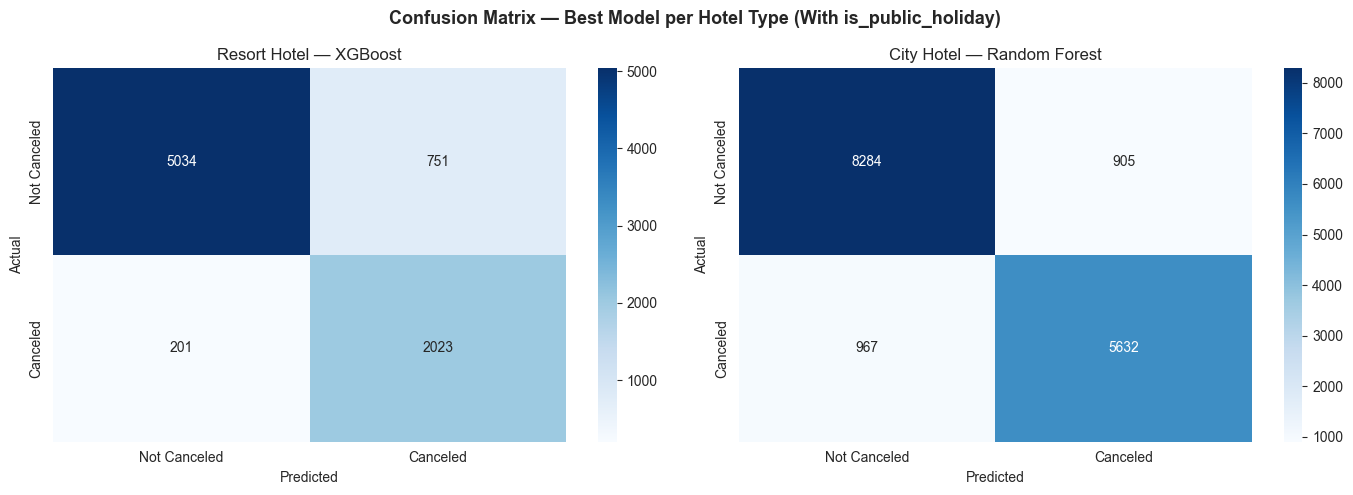

In [19]:
# --- 7.1 Confusion Matrices (best model per hotel type with holiday) ---

fig ,axes =plt .subplots (1 ,2 ,figsize =(14 ,5 ))
fig .suptitle ('Confusion Matrix — Best Model per Hotel Type (With is_public_holiday)',fontsize =13 ,fontweight ='bold')

best_model_configs =[
(resort_models_with_hol ['XGB']['model'],resort_data ['X_test_with_hol'],resort_data ['y_test'],'Resort Hotel — XGBoost',None ),
(city_models_with_hol ['RF']['model'],city_data ['X_test_with_hol'],city_data ['y_test'],'City Hotel — Random Forest',None ),
]

for idx ,(model ,X_t ,y_t ,title ,scaler )in enumerate (best_model_configs ):
    X_eval =scaler .transform (X_t )if scaler else X_t 
    y_pred =model .predict (X_eval )
    cm =confusion_matrix (y_t ,y_pred )
    sns .heatmap (cm ,annot =True ,fmt ='d',cmap ='Blues',ax =axes [idx ],
    xticklabels =['Not Canceled','Canceled'],
    yticklabels =['Not Canceled','Canceled'])
    axes [idx ].set_title (title )
    axes [idx ].set_xlabel ('Predicted')
    axes [idx ].set_ylabel ('Actual')

plt .tight_layout ()
plt .savefig (f'{FIGURES_DIR }/confusion_matrix_best_models.png',dpi =150 ,bbox_inches ='tight')
plt .show ()

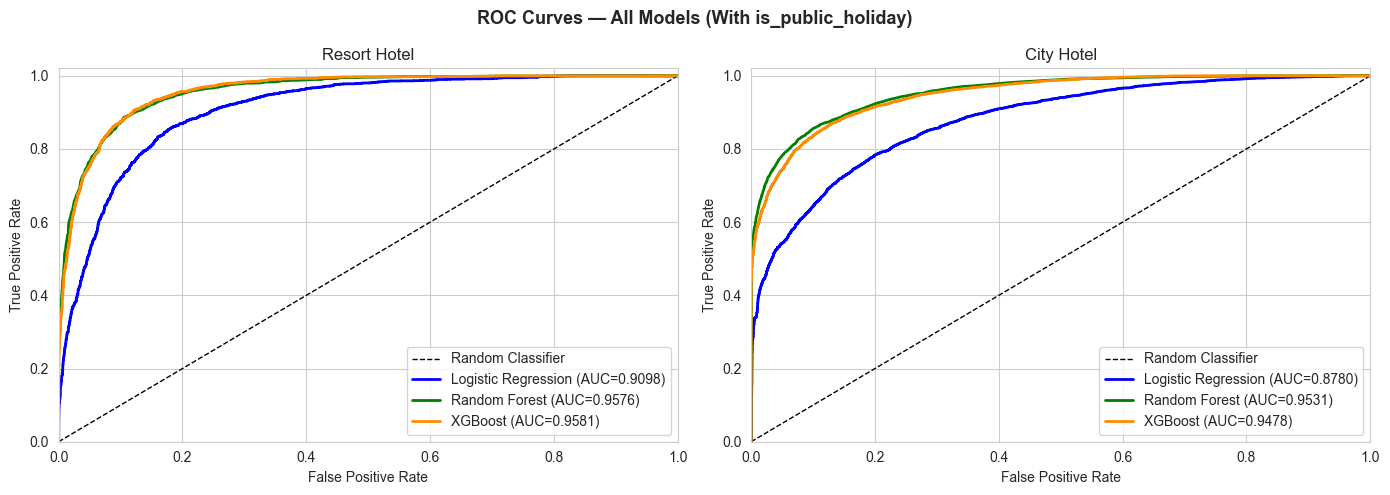

In [20]:
# --- 7.2 ROC Curves (all 3 models, both hotel types, with holiday) ---
fig ,axes =plt .subplots (1 ,2 ,figsize =(14 ,5 ))
fig .suptitle ('ROC Curves — All Models (With is_public_holiday)',fontsize =13 ,fontweight ='bold')

model_colors ={'LR':'blue','RF':'green','XGB':'darkorange'}
model_labels ={'LR':'Logistic Regression','RF':'Random Forest','XGB':'XGBoost'}

for idx ,(models_dict ,data ,title )in enumerate ([
(resort_models_with_hol ,resort_data ,'Resort Hotel'),
(city_models_with_hol ,city_data ,'City Hotel'),
]):
    axes [idx ].plot ([0 ,1 ],[0 ,1 ],'k--',lw =1 ,label ='Random Classifier')
    for key in ['LR','RF','XGB']:
        m =models_dict [key ]['model']
        scaler =models_dict [key ].get ('scaler')
        X_eval =scaler .transform (data ['X_test_with_hol'])if scaler else data ['X_test_with_hol']
        y_prob =m .predict_proba (X_eval )[:,1 ]
        fpr ,tpr ,_ =roc_curve (data ['y_test'],y_prob )
        roc_auc =auc (fpr ,tpr )
        axes [idx ].plot (fpr ,tpr ,color =model_colors [key ],lw =2 ,
        label =f'{model_labels [key ]} (AUC={roc_auc :.4f})')
    axes [idx ].set_xlim ([0 ,1 ]);axes [idx ].set_ylim ([0 ,1.02 ])
    axes [idx ].set_xlabel ('False Positive Rate');axes [idx ].set_ylabel ('True Positive Rate')
    axes [idx ].set_title (title );axes [idx ].legend (loc ='lower right')

plt .tight_layout ()
plt .savefig (f'{FIGURES_DIR }/roc_curves_all_models.png',dpi =150 ,bbox_inches ='tight')
plt .show ()

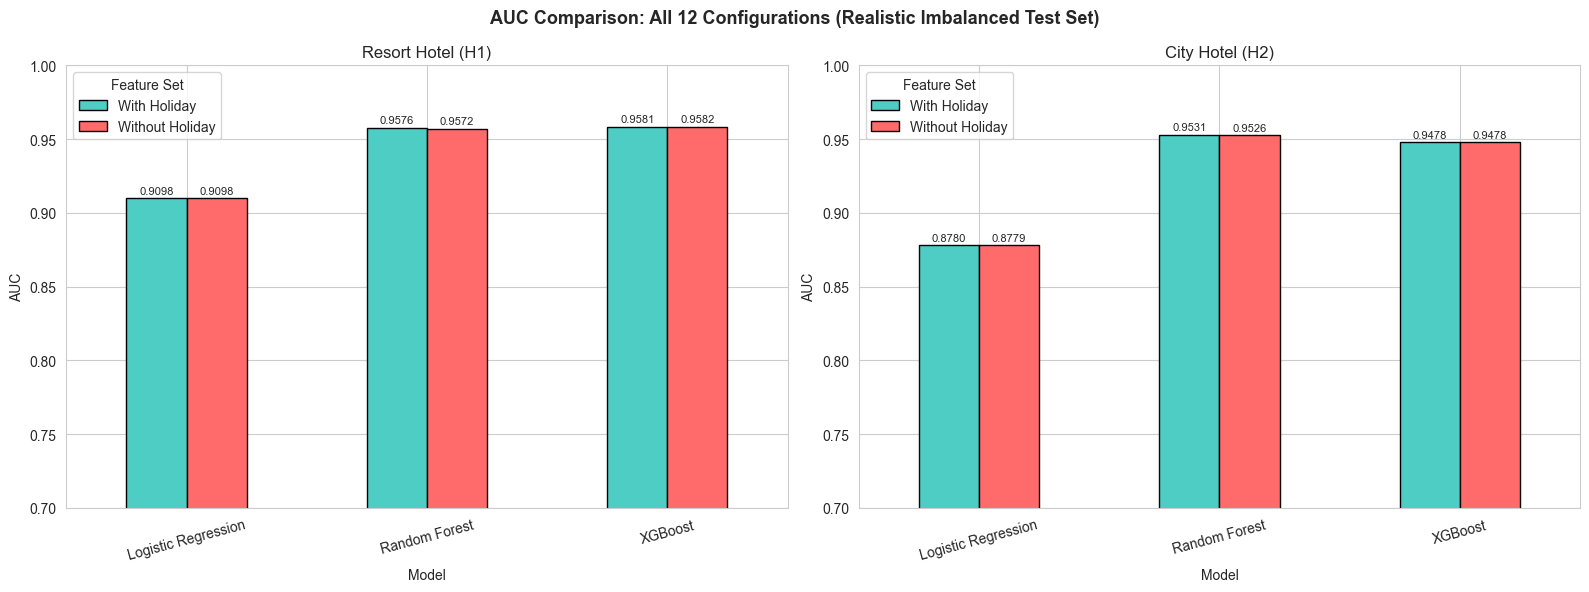

In [21]:
# --- 7.3 AUC comparison bar chart (all 12 configurations) ---
fig ,axes =plt .subplots (1 ,2 ,figsize =(16 ,6 ))
fig .suptitle ('AUC Comparison: All 12 Configurations (Realistic Imbalanced Test Set)',fontsize =13 ,fontweight ='bold')

for ax ,comparison ,hotel_name in [
(axes [0 ],resort_comparison ,'Resort Hotel (H1)'),
(axes [1 ],city_comparison ,'City Hotel (H2)'),
]:
    pivot =comparison .pivot (index ='Model',columns ='Feature',values ='AUC')
    pivot .plot (kind ='bar',ax =ax ,color =['#4ECDC4','#FF6B6B'],edgecolor ='black')
    ax .set_title (hotel_name );ax .set_ylabel ('AUC')
    ax .set_ylim ([0.7 ,1.0 ]);ax .set_xticklabels (ax .get_xticklabels (),rotation =15 )
    ax .legend (title ='Feature Set')
    for container in ax .containers :
        ax .bar_label (container ,fmt ='%.4f',padding =2 ,fontsize =8 )

plt .tight_layout ()
plt .savefig (f'{FIGURES_DIR }/auc_comparison.png',dpi =150 ,bbox_inches ='tight')
plt .show ()

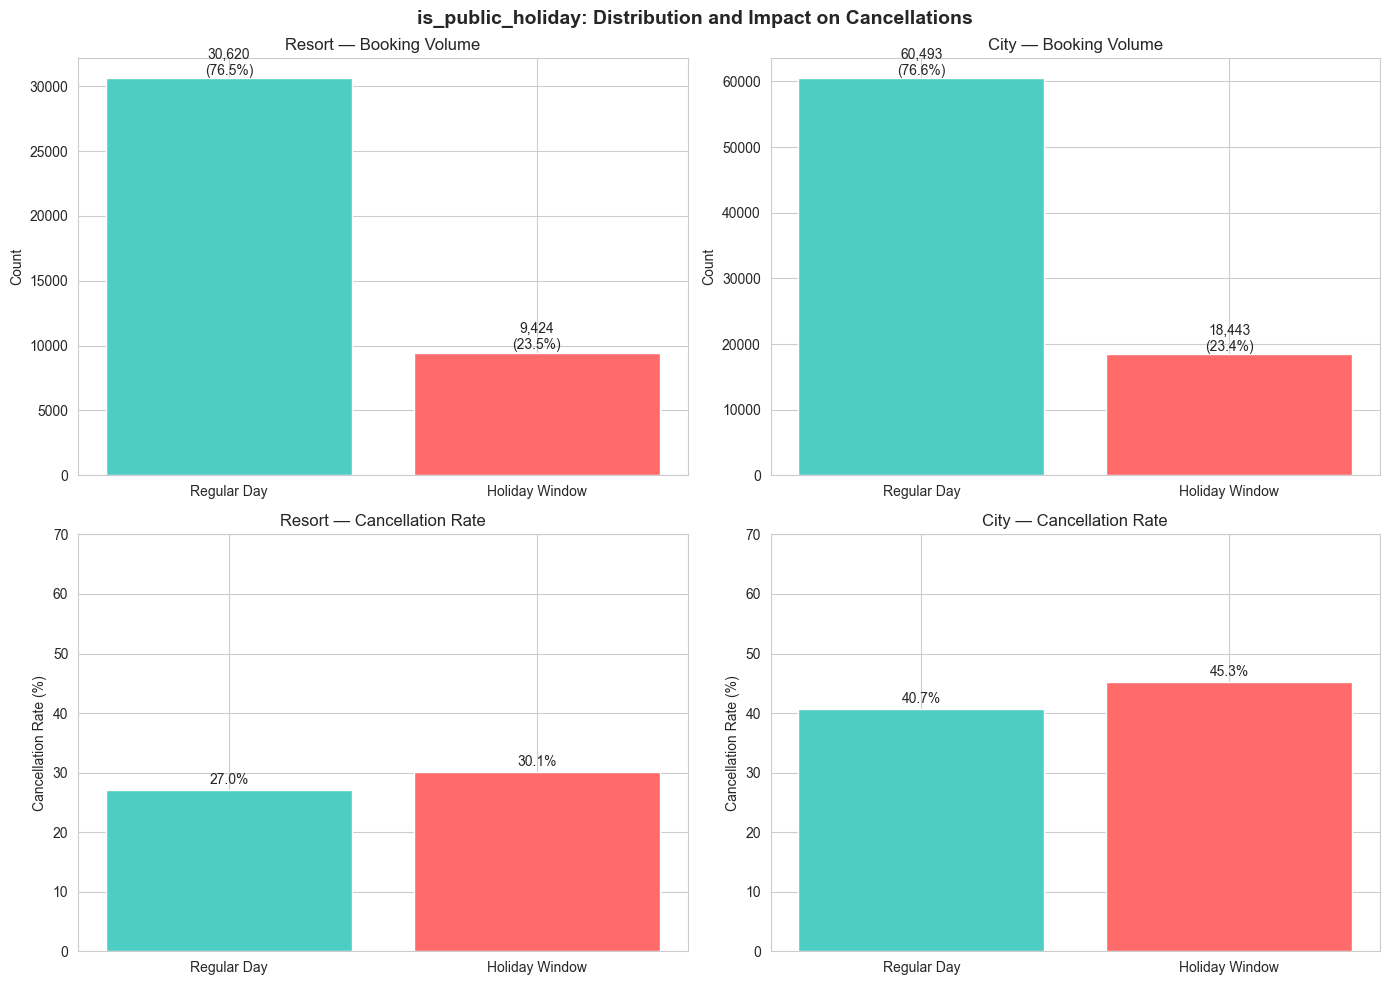

In [22]:
# --- 7.4 Public Holiday Distribution & Impact ---
fig ,axes =plt .subplots (2 ,2 ,figsize =(14 ,10 ))
fig .suptitle ('is_public_holiday: Distribution and Impact on Cancellations',
fontsize =14 ,fontweight ='bold')
colors =['#4ECDC4','#FF6B6B']

for col ,(df_src ,hotel_name )in enumerate ([
(df_resort ,'Resort'),(df_city ,'City')
]):
    counts =df_src ['is_public_holiday'].value_counts ().sort_index ()
    bars =axes [0 ,col ].bar (['Regular Day','Holiday Window'],counts .values ,
    color =['#4ECDC4','#FF6B6B'])
    axes [0 ,col ].set_title (f'{hotel_name } — Booking Volume')
    axes [0 ,col ].set_ylabel ('Count')
    for bar ,val in zip (bars ,counts .values ):
        axes [0 ,col ].text (bar .get_x ()+bar .get_width ()/2 ,
        bar .get_height ()+50 ,
        f'{val :,}\n({val /len (df_src )*100 :.1f}%)',
        ha ='center',va ='bottom')

    cancel_rates =df_src .groupby ('is_public_holiday')['is_canceled'].mean ()*100 
    bars2 =axes [1 ,col ].bar (['Regular Day','Holiday Window'],cancel_rates .values ,
    color =['#4ECDC4','#FF6B6B'])
    axes [1 ,col ].set_title (f'{hotel_name } — Cancellation Rate')
    axes [1 ,col ].set_ylabel ('Cancellation Rate (%)')
    axes [1 ,col ].set_ylim ([0 ,70 ])
    for bar ,val in zip (bars2 ,cancel_rates .values ):
        axes [1 ,col ].text (bar .get_x ()+bar .get_width ()/2 ,
        bar .get_height ()+0.5 ,f'{val :.1f}%',
        ha ='center',va ='bottom')

plt .tight_layout ()
plt .savefig (f'{FIGURES_DIR }/holiday_analysis.png',dpi =150 ,bbox_inches ='tight')
plt .show ()

## 8. SHAP Analysis (Explainable AI)



**CR2 Weakness 3:** Cross-hotel SHAP comparison uses different model types (XGBoost for Resort, RF for City), producing values on fundamentally different scales. **Normalized SHAP values (% of total)** are computed to enable valid cross-hotel comparison of relative feature importance. Absolute SHAP magnitudes should NOT be compared directly across hotel types.

In [23]:
TOP_K =15 
DEP_FEATURES =['lead_time','arrival_date_month','adr','is_public_holiday']

def run_shap_analysis (model ,X_test ,hotel_name ,model_name ,out_dir ):
    """
    Full SHAP analysis: bar plot, beeswarm, dependence plots, top-features CSV.
    MW Fix 6: Reports actual rank of is_public_holiday across ALL features.
    CR2 Weakness 3: Adds normalized SHAP (% of total) for cross-hotel comparison.
    Uses fewer samples for RandomForest (slower) to avoid timeout.
    """
    os .makedirs (out_dir ,exist_ok =True )
    prefix =hotel_name .split ()[0 ]

    # RF SHAP is much slower than XGBoost — use smaller sample to keep runtime feasible
    is_rf ='RandomForest'in model_name or 'RF'in model_name 
    max_samples =500 if is_rf else 2000 
    n_samples =min (max_samples ,len (X_test ))
    X_sample =X_test .sample (n =n_samples ,random_state =RANDOM_STATE )

    print (f'  Computing SHAP values for {hotel_name } ({model_name }, n={n_samples })...')
    explainer =shap .TreeExplainer (model )
    shap_values =explainer .shap_values (X_sample ,approximate =is_rf )

    # Normalise to 2-D array (samples × features) for the positive class
    if hasattr (shap_values ,'values'):
        shap_matrix =shap_values .values 
    elif isinstance (shap_values ,list ):
        shap_matrix =np .array (shap_values [1 ]if len (shap_values )>=2 else shap_values [0 ])
    else :
        shap_matrix =np .array (shap_values )

        # Handle 3-D output (samples × features × classes) from RF approximate mode
    if shap_matrix .ndim ==3 :
        shap_matrix =shap_matrix [:,:,1 ]# take positive-class SHAP values
    if shap_matrix .ndim ==1 :
        shap_matrix =shap_matrix .reshape (-1 ,1 )
    if shap_matrix .shape [1 ]>X_sample .shape [1 ]:
        shap_matrix =shap_matrix [:,:X_sample .shape [1 ]]


    mean_abs =np .abs (shap_matrix ).mean (axis =0 )
    total_shap =mean_abs .sum ()

    # CR2 Weakness 3: Normalized SHAP (% of total) for cross-hotel comparison
    pct_of_total =(mean_abs /total_shap *100 ).round (2 )if total_shap >0 else mean_abs *0 

    all_ranked =pd .DataFrame ({
    'feature':X_sample .columns ,
    'mean_|SHAP|':mean_abs .round (4 ),
    'pct_of_total':pct_of_total ,
    'rank':pd .Series (mean_abs ).rank (ascending =False ).astype (int ).values 
    }).sort_values ('rank')
    all_ranked .to_csv (f'{out_dir }/{prefix }_{model_name }_all_shap_ranked.csv',index =False )

    top_idx =np .argsort (mean_abs )[::-1 ][:TOP_K ]
    top_features =all_ranked .head (TOP_K )
    top_features .to_csv (f'{out_dir }/{prefix }_{model_name }_top_shap.csv',index =False )
    print (f'  Top 5 features: {list (top_features ["feature"].head ())}')


    hol_row =all_ranked [all_ranked ['feature']=='is_public_holiday']
    if len (hol_row )>0 :
        print (f'  is_public_holiday: rank {hol_row ["rank"].values [0 ]} of {len (all_ranked )} features | '
        f'mean |SHAP| = {hol_row ["mean_|SHAP|"].values [0 ]} | '
        f'{hol_row ["pct_of_total"].values [0 ]:.2f}% of total')
    else :
        print (f'  is_public_holiday: not found in features')

        # Beeswarm plot
    with warnings .catch_warnings ():
        warnings .filterwarnings ('ignore',message ='.*NumPy global RNG.*',category =FutureWarning )
        shap .summary_plot (shap_matrix ,X_sample ,show =False )
    plt .title (f'{prefix } – {model_name } SHAP (Beeswarm)')
    plt .tight_layout ()
    plt .savefig (f'{out_dir }/{prefix }_{model_name }_SHAP_beeswarm.png',dpi =200 ,bbox_inches ='tight')
    plt .close ()

    # Bar plot (top K)
    with warnings .catch_warnings ():
        warnings .filterwarnings ('ignore',message ='.*NumPy global RNG.*',category =FutureWarning )
        shap .summary_plot (shap_matrix [:,top_idx ],X_sample .iloc [:,top_idx ],
        plot_type ='bar',show =False )
    plt .title (f'{prefix } – {model_name } SHAP (Top {TOP_K } Features)')
    plt .tight_layout ()
    plt .savefig (f'{out_dir }/{prefix }_{model_name }_SHAP_bar.png',dpi =200 ,bbox_inches ='tight')
    plt .close ()

    # Dependence plots
    for feat in DEP_FEATURES :
        if feat in X_sample .columns :
            feat_idx =list (X_sample .columns ).index (feat )
            with warnings .catch_warnings ():
                warnings .filterwarnings ('ignore',message ='.*NumPy global RNG.*',category =FutureWarning )
                shap .dependence_plot (feat_idx ,shap_matrix ,X_sample ,show =False )
            plt .title (f'{prefix } – {model_name } SHAP Dependence: {feat }')
            plt .tight_layout ()
            plt .savefig (f'{out_dir }/{prefix }_{model_name }_SHAP_dep_{feat }.png',dpi =200 ,bbox_inches ='tight')
            plt .close ()

    print (f'  SHAP complete. Files saved to {out_dir }/')
    return top_features ,shap_matrix ,X_sample ,all_ranked 

In [24]:
print ('='*80 )
print ('SHAP ANALYSIS — Best Model per Hotel Type')
print ('Resort: XGBoost (best AUC) | City: Random Forest (best AUC)')
print ('='*80 )

# Resort: XGBoost is typically best
resort_shap_top ,resort_shap_matrix ,resort_shap_X ,resort_shap_all =run_shap_analysis (
resort_models_with_hol ['XGB']['model'],
resort_data ['X_test_with_hol'],
'Resort Hotel (H1)','XGBoost',SHAP_DIR 
)


city_shap_top ,city_shap_matrix ,city_shap_X ,city_shap_all =run_shap_analysis (
city_models_with_hol ['RF']['model'],
city_data ['X_test_with_hol'],
'City Hotel (H2)','RandomForest',SHAP_DIR 
)

print ('\n--- Resort Hotel: Top SHAP Features ---')
print (resort_shap_top .to_string (index =False ))
print ('\n--- City Hotel: Top SHAP Features ---')
print (city_shap_top .to_string (index =False ))

SHAP ANALYSIS — Best Model per Hotel Type
Resort: XGBoost (best AUC) | City: Random Forest (best AUC)
  Computing SHAP values for Resort Hotel (H1) (XGBoost, n=2000)...
  Top 5 features: ['country_PRT', 'required_car_parking_spaces', 'lead_time', 'total_of_special_requests', 'MS_Online TA']
  is_public_holiday: rank 43 of 64 features | mean |SHAP| = 0.01730000041425228 | 0.22% of total
  SHAP complete. Files saved to shap_outputs/
  Computing SHAP values for City Hotel (H2) (RandomForest, n=500)...
  Top 5 features: ['total_of_special_requests', 'country_PRT', 'lead_time', 'CT_Transient', 'adr']
  is_public_holiday: rank 31 of 64 features | mean |SHAP| = 0.0046 | 0.56% of total
  SHAP complete. Files saved to shap_outputs/

--- Resort Hotel: Top SHAP Features ---
                    feature  mean_|SHAP|  pct_of_total  rank
                country_PRT       1.3108         16.73     1
required_car_parking_spaces       1.0393         13.26     2
                  lead_time       0.6577   

### 8.1 Normalized SHAP Comparison Across Hotel Types (CR2 Weakness 3)

Since Resort uses XGBoost and City uses Random Forest, absolute SHAP magnitudes are not comparable. The normalized values (% of total mean |SHAP|) allow valid ordinal comparison of relative feature importance across hotel types.

In [25]:
# CR2 Weakness 3: Normalized cross-hotel SHAP comparison
print ('\n'+'='*80 )
print ('CROSS-HOTEL SHAP COMPARISON (Normalized — % of Total)')
print ('NOTE: Absolute SHAP magnitudes are NOT comparable across different model types.')
print ('      Normalized values (% of total) allow valid relative comparison.')
print ('='*80 )

# Merge on feature name
resort_norm =resort_shap_all [['feature','pct_of_total','rank']].rename (
columns ={'pct_of_total':'Resort_%','rank':'Resort_rank'})
city_norm =city_shap_all [['feature','pct_of_total','rank']].rename (
columns ={'pct_of_total':'City_%','rank':'City_rank'})
cross_comparison =resort_norm .merge (city_norm ,on ='feature',how ='outer').fillna (0 )
cross_comparison ['Avg_%']=((cross_comparison ['Resort_%']+cross_comparison ['City_%'])/2 ).round (2 )
cross_comparison =cross_comparison .sort_values ('Avg_%',ascending =False )

print ('\nTop 15 features by average normalized importance:')
print (cross_comparison .head (15 ).to_string (index =False ))

# Save
cross_comparison .to_csv (f'{RESULTS_DIR }/cross_hotel_shap_normalized.csv',index =False )
print (f'\nFull cross-hotel comparison saved to {RESULTS_DIR }/cross_hotel_shap_normalized.csv')

# Holiday features specifically
print ('\n--- Holiday-related features ---')
hol_features =cross_comparison [cross_comparison ['feature'].isin (['is_public_holiday','holiday_x_domestic'])]
if len (hol_features )>0 :
    print (hol_features .to_string (index =False ))
else :
    print ('  No holiday features found in SHAP ranking')


CROSS-HOTEL SHAP COMPARISON (Normalized — % of Total)
NOTE: Absolute SHAP magnitudes are NOT comparable across different model types.
      Normalized values (% of total) allow valid relative comparison.

Top 15 features by average normalized importance:
                    feature  Resort_%  Resort_rank  City_%  City_rank  Avg_%
                country_PRT     16.73            1   12.86          2  14.79
  total_of_special_requests      5.41            4   13.28          1   9.34
                  lead_time      8.39            3    9.29          3   8.84
required_car_parking_spaces     13.26            2    1.39         22   7.33
               CT_Transient      4.37            8    4.39          4   4.38
               MS_Online TA      5.06            5    3.63          7   4.34
                        adr      4.56            7    4.03          5   4.29
          arrival_date_year      4.56            6    3.19         10   3.87
                      ART_A      4.11            9 

## 9. Summary of Key Findings

In [26]:
print ('='*80 )
print ('FINAL RESULTS SUMMARY')
print ('='*80 )

def best_row (comparison ):
    return comparison .loc [comparison ['AUC'].idxmax ()]

for name ,comp in [('Resort Hotel (H1)',resort_comparison ),
('City Hotel   (H2)',city_comparison )]:
    best =best_row (comp )
    print (f'\n{name }')
    print (f'  Best model: {best ["Model"]} ({best ["Feature"]})')
    print (f'  Accuracy={best ["Accuracy"]:.4f} | F1={best ["F1 Score"]:.4f} | '
    f'AUC={best ["AUC"]:.4f} | PR-AUC={best ["PR-AUC"]:.4f}')


print (f'\nSHAP — is_public_holiday rank (ALL features):')
resort_hol =resort_shap_all [resort_shap_all ['feature']=='is_public_holiday']
city_hol =city_shap_all [city_shap_all ['feature']=='is_public_holiday']
print (f'  Resort (XGBoost): rank {resort_hol ["rank"].values [0 ]if len (resort_hol )else "N/A"} '
f'of {len (resort_shap_all )} | mean |SHAP| = {resort_hol ["mean_|SHAP|"].values [0 ]if len (resort_hol )else "N/A"} '
f'| {resort_hol ["pct_of_total"].values [0 ]if len (resort_hol )else "N/A"}% of total')
print (f'  City (RandomForest): rank {city_hol ["rank"].values [0 ]if len (city_hol )else "N/A"} '
f'of {len (city_shap_all )} | mean |SHAP| = {city_hol ["mean_|SHAP|"].values [0 ]if len (city_hol )else "N/A"} '
f'| {city_hol ["pct_of_total"].values [0 ]if len (city_hol )else "N/A"}% of total')

print ('\n'+'='*80 )
print ('BUG FIXES APPLIED (Critical Review 1)')
print ('='*80 )
print ('  Bug 1: hotel column dropped from feature matrix (zero-variance constant)')
print ('  Bug 2: 3 missing 2015 holidays added (Oct 5, Nov 1, Dec 1)')
print ('  Bug 3: One-hot reference columns dropped to remove perfect multicollinearity')

print ('\n'+'='*80 )
print ('BUG FIXES APPLIED (Critical Review 2)')
print ('='*80 )
print ('  CR2 Bug 1 (P0): LR penalty="elasticnet" set — l1_ratio now effective')
print ('  CR2 Bug 2 (P0): Temporal validation models actually trained and evaluated')
print ('  CR2 Bug 3 (P0): temporal_split_undersample uses df_hotel, not global df')

print ('\n'+'='*80 )
print ('METHODOLOGICAL IMPROVEMENTS (Critical Review 1)')
print ('='*80 )
print ('  MW1: Undersampling applied AFTER train/test split (train only)')
print ('  MW2: Temporal validation split added as robustness check')
print ('  MW3: Bootstrap 95% CI on AUC for statistical significance')
print ('  MW4: Best hyperparameters saved to CSV')
print ('  MW5: SHAP on best model per hotel (RF for City)')
print ('  MW6: Full SHAP rank of is_public_holiday reported')
print ('  MW7: Chi-squared test for holiday vs cancellation')
print ('  MW8: Targeted warning filters only')

print ('\n'+'='*80 )
print ('METHODOLOGICAL IMPROVEMENTS (Critical Review 2)')
print ('='*80 )
print ('  CR2-1: Cramér\'s V effect size added to chi-squared test')
print ('  CR2-2: PR-AUC metric added for imbalanced evaluation')
print ('  CR2-3: CV AUC ± std reported for all models')
print ('  CR2-4: SHAP normalized (% of total) for cross-hotel comparison')
print ('  CR2-5: Holiday window sensitivity analysis (±0 to ±7, including ±4)')
print ('  CR2-6: holiday_x_domestic interaction feature added')
print ('  CR2-7: ART_* data leakage acknowledged as limitation')
print ('  CR2-8: 0.5 threshold limitation acknowledged; AUC as primary metric')

print ('\n'+'='*80 )
print ('ACKNOWLEDGED LIMITATIONS')
print ('='*80 )
print ('  1. ART_* features (assigned_room_type) may constitute data leakage for')
print ('     booking-time prediction. Study predicts at any point before arrival.')
print ('  2. Default 0.5 decision threshold is suboptimal for imbalanced test set.')
print ('     AUC and PR-AUC (threshold-free) are the primary comparison metrics.')
print ('  3. arrival_date_year encodes temporal trends, not causal booking-level')
print ('     effects. It should be excluded from "actionable drivers" discussion.')
print ('  4. Random undersampling discards substantial majority-class data.')
print ('     Alternatives (class_weight, SMOTE, scale_pos_weight) should be')
print ('     explored in future work.')

print ('\n'+'='*80 )
print ('PIPELINE COMPLETE')
print ('='*80 )
print (f'\nOutput files:')
for d in [RESULTS_DIR ,FIGURES_DIR ,SHAP_DIR ]:
    files =os .listdir (d )
    print (f'\n  {d }/ ({len (files )} files)')
    for f in sorted (files ):
        print (f'    {f }')

FINAL RESULTS SUMMARY

Resort Hotel (H1)
  Best model: XGBoost (Without Holiday)
  Accuracy=0.8799 | F1=0.8078 | AUC=0.9582 | PR-AUC=0.9022

City Hotel   (H2)
  Best model: Random Forest (With Holiday)
  Accuracy=0.8814 | F1=0.8575 | AUC=0.9531 | PR-AUC=0.9448

SHAP — is_public_holiday rank (ALL features):
  Resort (XGBoost): rank 43 of 64 | mean |SHAP| = 0.01730000041425228 | 0.2199999988079071% of total
  City (RandomForest): rank 31 of 64 | mean |SHAP| = 0.0046 | 0.56% of total

BUG FIXES APPLIED (Critical Review 1)
  Bug 1: hotel column dropped from feature matrix (zero-variance constant)
  Bug 2: 3 missing 2015 holidays added (Oct 5, Nov 1, Dec 1)
  Bug 3: One-hot reference columns dropped to remove perfect multicollinearity

BUG FIXES APPLIED (Critical Review 2)
  CR2 Bug 1 (P0): LR penalty="elasticnet" set — l1_ratio now effective
  CR2 Bug 2 (P0): Temporal validation models actually trained and evaluated
  CR2 Bug 3 (P0): temporal_split_undersample uses df_hotel, not global df
